In [1]:
# !cp "/content/drive/MyDrive/Colab_Notebooks/Confirmed_fronts.zip" "/content/"
# !unzip -q "/content/Confirmed_fronts.zip"
img_dir = "/content/confirmed_fronts"

In [2]:
import pandas as pd
import os
import torch
from torch import nn
from torch import optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision.transforms import v2
import glob
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from sklearn.metrics import accuracy_score, f1_score
import torchvision.models as models

In [3]:
class CarColorDataset(Dataset):
    def __init__(self, root_dir, transform):
        self.root_dir = root_dir
        self.transform = transform

        search_path = os.path.join(root_dir, "**/*.jpg")
        self.file_paths = glob.glob(search_path, recursive=True)
        self.file_names = [os.path.basename(f) for f in self.file_paths]
        self.all_colors = sorted(list(set([f.split('$$')[3] for f in self.file_names])))
        self.color_to_idx = {color: i for i, color in enumerate(self.all_colors)}
        print(f"Найдено цветов: {len(self.all_colors)}")

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        file_name = os.path.basename(img_path)
        image = Image.open(img_path).convert('RGB')
        color_name = file_name.split('$$')[3]
        label = self.color_to_idx[color_name]
        image = self.transform(image)

        return image, torch.tensor(label)

transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [4]:
dataset = CarColorDataset(img_dir, transform)
dataset.all_colors

Найдено цветов: 23


['Beige',
 'Black',
 'Blue',
 'Bronze',
 'Brown',
 'Burgundy',
 'Gold',
 'Green',
 'Grey',
 'Indigo',
 'Magenta',
 'Maroon',
 'Multicolour',
 'Navy',
 'Orange',
 'Pink',
 'Purple',
 'Red',
 'Silver',
 'Turquoise',
 'Unlisted',
 'White',
 'Yellow']

In [5]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size]
)

In [17]:
train_dataloader = DataLoader(train_dataset,
                              256,
                              shuffle=True,
                              num_workers=4,
                              pin_memory=True,
                              persistent_workers=True)
test_dataloader = DataLoader(test_dataset,
                             256,
                             shuffle=False,
                             num_workers=4,
                             pin_memory=True,
                             persistent_workers=True
                             )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [7]:
def train(model, train_dataloader, criterion, optimizer, num_epoch):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    train_loss = []
    train_f1 = []

    for epoch in range(num_epoch):
        model.train()
        print(f"\nEpoch {epoch + 1}/{num_epoch}")

        running_loss = 0.0
        preds, targets = [], []

        for images, labels in tqdm(train_dataloader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            pred = outputs.argmax(dim=1)
            preds.extend(pred.detach().cpu().numpy())
            targets.extend(labels.detach().cpu().numpy())

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_dataloader.dataset)
        epoch_f1 = f1_score(targets, preds, average='macro')

        print(f"Loss: {epoch_loss:.4f} | F1: {epoch_f1:.4f}")

        train_loss.append(epoch_loss)
        train_f1.append(epoch_f1)

    return train_loss, train_f1


# efficientnet

In [8]:
eff_net = models.efficientnet_v2_s(
    weights=models.EfficientNet_V2_S_Weights.DEFAULT
)

for param in eff_net.parameters():
    param.requires_grad = False

in_features = eff_net.classifier[1].in_features
eff_net.classifier[1] = nn.Linear(in_features, len(dataset.all_colors))

optimizer = optim.Adam(eff_net.classifier[1].parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epoch = 10
train_loss_eff_net, train_f1_eff_net = train(eff_net, train_dataloader, criterion, optimizer, num_epoch)


Epoch 1/10


  0%|          | 0/194 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 194/194 [03:28<00:00,  1.08s/it]


Loss: 1.5084 | F1: 0.1869

Epoch 2/10


100%|██████████| 194/194 [03:18<00:00,  1.02s/it]


Loss: 1.2108 | F1: 0.2431

Epoch 3/10


...

Loss: 1.0984 | F1: 0.3236

Epoch 9/10


100%|██████████| 194/194 [03:16<00:00,  1.01s/it]


Loss: 1.0941 | F1: 0.3307

Epoch 10/10


100%|██████████| 194/194 [03:16<00:00,  1.01s/it]


Loss: 1.0924 | F1: 0.3327


# swin

In [9]:
swin = models.swin_v2_t(weights=models.Swin_V2_T_Weights.DEFAULT)
for param in swin.parameters():
    param.requires_grad = False

swin.head = nn.Linear(swin.head.in_features, len(dataset.all_colors))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(swin.head.parameters(), lr=0.001, weight_decay=1e-4)
num_epoch = 10
train_loss_swin, train_f1_swin = train(swin, train_dataloader, criterion, optimizer, num_epoch)

Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth


100%|██████████| 109M/109M [00:00<00:00, 190MB/s]



Epoch 1/10


100%|██████████| 194/194 [04:24<00:00,  1.37s/it]


Loss: 1.5060 | F1: 0.1736

Epoch 2/10


...

Loss: 0.8762 | F1: 0.3521

Epoch 9/10


100%|██████████| 194/194 [04:24<00:00,  1.36s/it]


Loss: 0.8606 | F1: 0.3566

Epoch 10/10


100%|██████████| 194/194 [04:24<00:00,  1.36s/it]

Loss: 0.8529 | F1: 0.3608


# My

In [15]:
class MyNet(nn.Module):
    def __init__(self, out_ch):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Linear(256, out_ch)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.head(x)
        return x

In [18]:
my_net = MyNet(len(dataset.all_colors))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(my_net.parameters(), lr=0.001, weight_decay=1e-4)
num_epoch = 10
train_loss_my_net, train_f1_my_net = train(my_net, train_dataloader, criterion, optimizer, num_epoch)



Epoch 1/10


  0%|          | 0/194 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 194/194 [03:07<00:00,  1.04it/s]


Loss: 1.2016 | F1: 0.2408

Epoch 2/10


100%|██████████| 194/194 [03:07<00:00,  1.04it/s]


Loss: 0.9231 | F1: 0.3027

Epoch 3/10


...

Loss: 0.6593 | F1: 0.3809

Epoch 9/10


100%|██████████| 194/194 [03:04<00:00,  1.05it/s]


Loss: 0.6409 | F1: 0.3840

Epoch 10/10


100%|██████████| 194/194 [03:04<00:00,  1.05it/s]


Loss: 0.6198 | F1: 0.3960


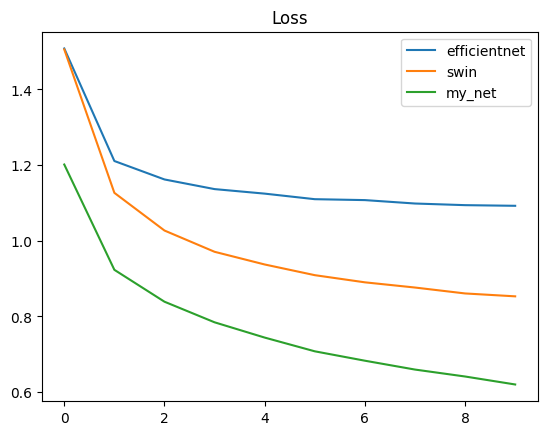

In [27]:
plt.plot(train_loss_eff_net, label='efficientnet')
plt.plot(train_loss_swin, label='swin')
plt.plot(train_loss_my_net, label='my_net')
plt.title('Loss')
plt.legend()
plt.show()

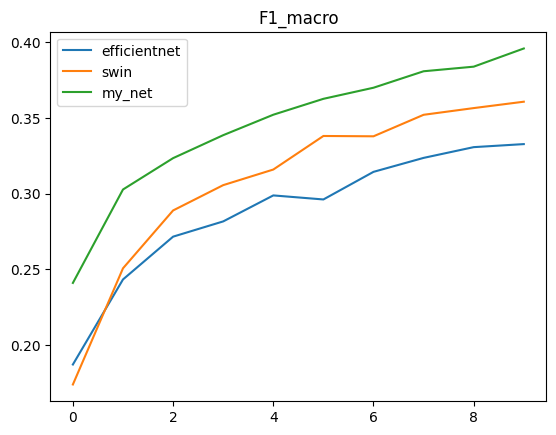

In [28]:
plt.plot(train_f1_eff_net, label='efficientnet')
plt.plot(train_f1_swin, label='swin')
plt.plot(train_f1_my_net, label='my_net')
plt.title('F1_macro')
plt.legend()
plt.show()

# Сравнение на test

In [23]:
def test(model, criterion, dataloader):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    model.eval()
    test_loss = 0.0
    test_f1 = 0.0
    preds = []
    targets = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            pred = outputs.argmax(dim=1)
            preds.extend(pred.detach().cpu().numpy())
            targets.extend(labels.detach().cpu().numpy())

    test_loss /= len(dataloader.dataset)
    test_f1 = f1_score(targets, preds, average='macro')

    return test_loss, test_f1

In [24]:
test_loss_eff, test_f1_eff = test(eff_net, criterion, test_dataloader)
test_loss_swin, test_f1_swin = test(swin, criterion, test_dataloader)
test_loss_my, test_f1_my = test(my_net, criterion, test_dataloader)

100%|██████████| 49/49 [00:43<00:00,  1.12it/s]


In [25]:
print(f"efficient loss: {test_loss_eff:.2f} | f1: {test_f1_eff:.2f}")
print(f"swin      loss: {test_loss_swin:.2f} | f1: {test_f1_swin:.2f}")
print(f"my        loss: {test_loss_my:.2f} | f1: {test_f1_my:.2f}")

efficient loss: 1.03 | f1: 0.36
swin      loss: 0.80 | f1: 0.39
my        loss: 0.91 | f1: 0.38
